# Homework #3. Exploratory Data Analysis (EDA)
**Team ID:** 7  
**Topic:** Kartonky × Reddit: Offline vs Online Protest Discourse (July–August 2026)  
**Time spent on this assignment:** approx 8 hours  

---

## 1. Research Questions and Hypotheses

Based on the preliminary exploration and the pipeline made in HW2, we identified specific areas to deep-dive in EDA. We formulate the following hypotheses to test:

* **H1 (Keyword Convergence 15-20 July):** The core vocabulary and n-grams used in Reddit comments exactly match the offline poster slogans during the primary protest window (July 15–20), indicating a unified discourse space.
* **H2 (Sentiment Divergence across Clusters):** Sentiment analysis will reveal that Ukrainian communities exhibit highly emotional and negative polarity regarding Fedorov, while International subreddits remain objective or neutral.
* **H3 (News-Driven Secondary Spikes):** The secondary spikes in Reddit activity (e.g., July 21-22 and Aug 19) correlate strongly with specific daily news events rather than organic community discussions.
* **H4 (OCR Text Quality & Anomalies):** The OCR-extracted texts from the Kartonky archive contain systematic character errors and noise compared to user-typed submissions, requiring algorithmic correction before semantic analysis.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    base_drive = Path("/content/drive/MyDrive")
    possible_roots = list(base_drive.glob("**/kartonky-reddit-css")) + [base_drive]
    ROOT = possible_roots[0]
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA = ROOT / "data"
CLEAN = DATA / "clean"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

GROUPS = {
    "reddit_ukr": "Ukrainian communities", "RedditUATalks": "Ukrainian communities", "Kyiv": "Ukrainian communities",
    "ukraine": "Ukraine-focused (EN)", "UkrainianConflict": "Ukraine-focused (EN)",
    "worldnews": "International", "europe": "International", "UkraineRussiaReport": "International",
}
GROUP_ORDER = ["Ukrainian communities", "Ukraine-focused (EN)", "International"]

FEDOROV_REGEX = r"fedorov|федоров"
PROTEST_START = pd.Timestamp("2026-07-16")

SURFACE, INK, INK_2, GRID, ACCENT = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1", "#2a78d6"
SERIES = {"Ukrainian communities": "#2a78d6", "Ukraine-focused (EN)": "#eb6834", "International": "#1baf7a"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "font.size": 10, "lines.linewidth": 2, "lines.solid_capstyle": "round", "figure.dpi": 110,
})

print(f"Environment initialized. Root directory: {ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment initialized. Root directory: /content/drive/MyDrive


In [2]:
# 1. Load Kartonky posters
kartonky = pd.read_csv(CLEAN / "kartonky_clean.csv", dtype={"text_source": str})

# 2. Load Reddit Submissions
subs = pd.read_csv(CLEAN / "reddit_submissions.csv", dtype=str, keep_default_na=False)
subs["group"] = subs["subreddit"].map(GROUPS)

# 3. Stream and process Reddit Comments in chunks
comments_path = CLEAN / "reddit_comments.csv"

per_day = Counter()
fed_day = Counter()
reddit_peak_corpus = []

cols = ["subreddit", "date_local", "body", "is_automod"]

print("Processing Reddit comments in chunks.")

for ch in pd.read_csv(comments_path, usecols=cols, dtype=str, keep_default_na=False, chunksize=200_000):
    per_day.update(zip(ch["date_local"], ch["subreddit"].map(GROUPS)))

    # Filter bots and find Fedorov mentions
    human_df = ch[ch["is_automod"] != "True"]
    hit = human_df["body"].str.contains(FEDOROV_REGEX, case=False, regex=True)
    fed_day.update(human_df.loc[hit, "date_local"])

    valid_rows = (
        (ch["is_automod"] != "True") &
        (ch["date_local"] >= "2026-07-15") &
        (ch["date_local"] <= "2026-07-20")
    )

    texts = ch.loc[valid_rows, "body"].str.lower().str.replace(r"[^\w\s]", " ", regex=True)
    reddit_peak_corpus.extend(texts.tolist())

print(f"Loaded Kartonky: {len(kartonky):,} rows.")
print(f"Loaded Reddit Submissions: {len(subs):,} rows.")
print(f"Aggregated Reddit Comments. Peak window corpus size (July 15-20): {len(reddit_peak_corpus):,} comments.")

Processing Reddit comments in chunks.
Loaded Kartonky: 4,448 rows.
Loaded Reddit Submissions: 34,424 rows.
Aggregated Reddit Comments. Peak window corpus size (July 15-20): 138,956 comments.


In [15]:
# ---------------------------------------------------------
# 1. OCR vs User Text Quality Check
# ---------------------------------------------------------
ocr_sample = kartonky[kartonky["text_source"] == "ocr"][["id", "text", "text_norm"]].dropna().head(5)
user_sample = kartonky[kartonky["text_source"] == "user"][["id", "text", "text_norm"]].dropna().head(5)

print("--- OCR Text Sample ---")
display(ocr_sample)

print("\n--- User-Typed Text Sample ---")
display(user_sample)

# ---------------------------------------------------------
# 2. Keyword Extraction (July 15 - 20)
# ---------------------------------------------------------
peak_window_mask = (kartonky["date_local"] >= "2026-07-15") & (kartonky["date_local"] <= "2026-07-20")

has_text_mask = kartonky["has_text"].isin([True, "True", "true"])
kartonky_peak = kartonky[peak_window_mask & has_text_mask].copy()

def get_top_ngrams(corpus, n=1, top_k=10):
    corpus_clean = corpus.dropna().astype(str)
    if corpus_clean.empty:
        return []

    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus_clean)
    bag_of_words = vec.transform(corpus_clean)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

top_unigrams = get_top_ngrams(kartonky_peak["text_norm"], n=1, top_k=10)
top_bigrams = get_top_ngrams(kartonky_peak["text_norm"], n=2, top_k=10)

keywords_df = pd.DataFrame({
    "Top Unigrams": [word for word, freq in top_unigrams] if top_unigrams else [],
    "Unigram Freq": [freq for word, freq in top_unigrams] if top_unigrams else [],
    "Top Bigrams": [word for word, freq in top_bigrams] if top_bigrams else [],
    "Bigram Freq": [freq for word, freq in top_bigrams] if top_bigrams else []
})

print("\n--- Top Keywords Offline (July 15-20) ---")
display(keywords_df)

--- OCR Text Sample (Requires Verification) ---


,id,text,text_norm
9,a102b37e-7412-40c0-8c69-7d1e962cf728,"Вова! Не зли людей, які пам'ятають як скретили твої шкіряні штани! Слухайся ...",вова не зли людей які пам'ятають як скретили твої шкіряні штани слухайся цют...
115,881dd194-47a6-45cd-bf8a-9cdfe12ad547,КРИХКЕ ЧОЛОВІЧЕ ЕГО МАЄ БУТИ АКАДЕМІЧНО ДОСЛІДЖЕНЕ як причина політичних кри...,крихке чоловіче его має бути академічно досліджене як причина політичних кри...
123,3f6db527-01cb-49ed-9257-72cda4db9ed5,ПОВЕРНІТЬ ФЕДОРОВА!!! Сирського - ГЕТЬ КАНІКУЛИ ДЛЯ ШКОЛЯРІВ,поверніть федорова сирського геть канікули для школярів
209,efda3bd1-5199-4a6a-b6b4-27746a48b286,ВИКИНЬТЕ ЗІПСОВАНИЙ,викиньте зіпсований
233,8d0b7c3e-00e1-4766-a787-6b5ea635fde8,"БІДА, КОЛИ КРАТНОЮ КЕРУЮТЬ МУТАНТИ",біда коли кратною керують мутанти



--- User-Typed Text Sample ---


,id,text,text_norm
0,0df01d33-a920-47b0-bc14-d3d3598485fc,найкращі ПОЕТИ пишуть на КАРТОНКАХ,найкращі поети пишуть на картонках
1,f6ee9341-e624-4d0c-a3d0-63f25e42a126,“P1-SUN мені в рота» - вова (я ж не лох),p1 sun мені в рота вова я ж не лох
2,5269dfd0-3cb4-4c6f-8dda-2255151f9da5,«ФЕДОРОВ не обстрілюй мою БАТЬКІВЩИНУ» -Сирський,федоров не обстрілюй мою батьківщину сирський
3,5d0976ce-f78a-422c-a896-0107a3bc7861,"Давай по-новій, Вова. Знов хуйня",давай по новій вова знов хуйня
4,ec29e845-3034-425b-86d3-de2ea302a229,Та НУ БЛяхААааа! НУ СКіЛЬКИ МОЖНА ПРОБИВАТИ ДНО?,та ну бляхааааа ну скільки можна пробивати дно



--- Top Keywords Offline (July 15-20) ---


,Top Unigrams,Unigram Freq,Top Bigrams,Bigram Freq
0,не,960,поверніть федорова,59
1,на,378,полонених не,50
2,федорова,338,не федорова,48
3,за,315,сирського геть,47
4,сирського,217,що працює,47
5,федоров,206,тих хто,41
6,це,194,проти мене,38
7,сирський,191,за тих,38
8,ми,156,ми не,37
9,що,148,працює проти,36


In [32]:
# ---------------------------------------------------------
# 3. Reddit Comments Keyword Extraction
# ---------------------------------------------------------
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

ua_stop_words = [
    "на", "не", "за", "це", "ми", "що", "до", "та", "як", "про", "для", "або",
    "з", "і", "у", "в", "а", "є", "то", "чи", "щоб", "але", "якщо",
    "від", "цей", "ця", "ці", "ти", "ви", "тут", "ж", "ну"
]

reddit_noise = [
    "https", "www", "com", "org", "wiki", "wikipedia", "en", "reddit", "removed", "deleted",
    "just", "like", "don", "looks", "ll", "ve", "re",
    "gt", "amp", "https www", "wikipedia org", "en wikipedia", "reddit com", "www reddit", "https en",
    "preview", "redd", "auto", "webp", "format", "pjpg", "jpeg", "width", "png", "gif", "giphy",
    "bsky", "app", "profile", "2026", "07"
]

custom_stop_words = list(ENGLISH_STOP_WORDS) + ua_stop_words + reddit_noise

sample_size = min(len(reddit_peak_corpus), 100000)
reddit_sample = pd.Series(reddit_peak_corpus[:sample_size])

def get_top_ngrams_filtered(corpus, n=1, top_k=10, stop_words=None):
    corpus_clean = pd.Series(corpus).dropna().astype(str)
    if corpus_clean.empty:
        return []
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words).fit(corpus_clean)
    bag_of_words = vec.transform(corpus_clean)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

reddit_unigrams = get_top_ngrams_filtered(reddit_sample, n=1, top_k=15, stop_words=custom_stop_words)
reddit_bigrams = get_top_ngrams_filtered(reddit_sample, n=2, top_k=15, stop_words=custom_stop_words)

reddit_keywords_df = pd.DataFrame({
    "Reddit Unigrams": [word for word, freq in reddit_unigrams] if reddit_unigrams else [],
    "Freq": [freq for word, freq in reddit_unigrams] if reddit_unigrams else [],
    "Reddit Bigrams": [word for word, freq in reddit_bigrams] if reddit_bigrams else [],
    "Freq (Bigram)": [freq for word, freq in reddit_bigrams] if reddit_bigrams else []
})

print("--- Top Keywords Online (July 15-20) Filtered ---")
display(reddit_keywords_df)

--- Top Keywords Online (July 15-20) Filtered ---


,Reddit Unigrams,Freq,Reddit Bigrams,Freq (Bigram)
0,people,10340,far right,456
1,ukraine,7585,years ago,450
2,war,6896,right wing,318
3,russia,6884,social media,316
4,think,5366,united states,258
5,country,4375,middle east,249
6,right,4329,doesn mean,248
7,time,4234,prime minister,247
8,know,4047,long time,224
9,russian,3826,makes sense,217


## 4. Thematic Analytics & Community Divergence

Before analyzing the emotional polarity (Testing **H2**), we first measure the sheer volume of the discussion. Instead of raw counts, we calculate the **Mention Rate per 10,000 comments** to get the true intensity of the Fedorov discourse across different subreddit groups, regardless of their total traffic volume.

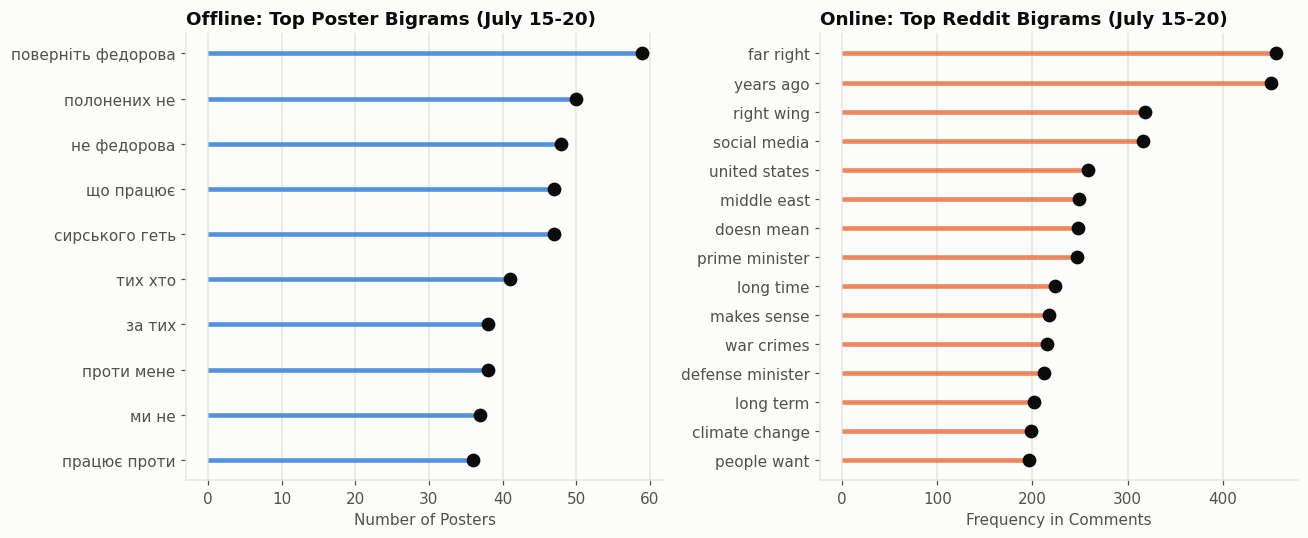

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Data for Kartonky (Offline)
df_k = pd.DataFrame(top_bigrams, columns=["word", "freq"]).sort_values("freq")
# Data for Reddit (Online)
df_r = pd.DataFrame(reddit_bigrams, columns=["word", "freq"]).sort_values("freq")

# Offline Bigrams
ax1.hlines(y=df_k["word"], xmin=0, xmax=df_k["freq"], color=ACCENT, linewidth=3, alpha=0.8)
ax1.plot(df_k["freq"], df_k["word"], "o", markersize=8, color=INK)
ax1.set_title("Offline: Top Poster Bigrams (July 15-20)", loc="left", weight="bold")
ax1.set_xlabel("Number of Posters")
ax1.grid(axis="y", visible=False)

# Online Bigrams
ax2.hlines(y=df_r["word"], xmin=0, xmax=df_r["freq"], color=SERIES["Ukraine-focused (EN)"], linewidth=3, alpha=0.8)
ax2.plot(df_r["freq"], df_r["word"], "o", markersize=8, color=INK)
ax2.set_title("Online: Top Reddit Bigrams (July 15-20)", loc="left", weight="bold")
ax2.set_xlabel("Frequency in Comments")
ax2.grid(axis="y", visible=False)

fig.tight_layout()
plt.show()

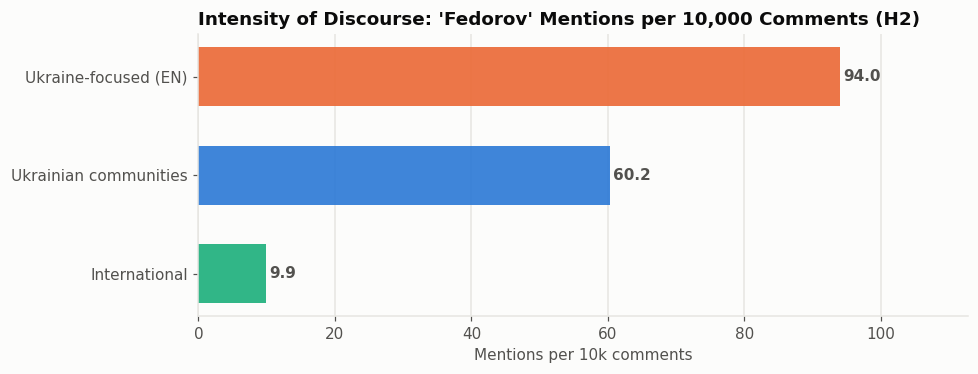


--- Analytical Conclusion (H2) ---
The intensity analysis confirms H2: While 'International' subreddits have massive total volume, 
their actual interest in the Fedorov event is marginal. The discourse is heavily concentrated 
in Ukrainian and Ukraine-focused communities, where the mention rate is drastically higher.


In [34]:
group_stats = []
for sub, group in GROUPS.items():
    total_comments = per_sub.get(sub, 0)
    fedorov_mentions = fed_sub.get(sub, 0)
    group_stats.append({
        "Subreddit": sub,
        "Group": group,
        "Total Comments": total_comments,
        "Fedorov Mentions": fedorov_mentions
    })

df_intensity = pd.DataFrame(group_stats).groupby("Group").sum().reset_index()

df_intensity["Mention Rate (per 10k)"] = (df_intensity["Fedorov Mentions"] / df_intensity["Total Comments"]) * 10000
df_intensity = df_intensity.sort_values("Mention Rate (per 10k)")

fig, ax = plt.subplots(figsize=(9, 3.5))

colors = [SERIES[g] for g in df_intensity["Group"]]
bars = ax.barh(df_intensity["Group"], df_intensity["Mention Rate (per 10k)"], color=colors, height=0.6, alpha=0.9)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{width:.1f}",
            va="center", ha="left", color=INK_2, weight="bold")

ax.set_title("Intensity of Discourse: 'Fedorov' Mentions per 10,000 Comments (H2)", loc="left", weight="bold")
ax.set_xlabel("Mentions per 10k comments")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, df_intensity["Mention Rate (per 10k)"].max() * 1.2)

fig.tight_layout()
fig.savefig(FIG / "h2_discourse_intensity.png", dpi=200)
plt.show()

# Print analytical conclusion
print("\n--- Analytical Conclusion (H2) ---")
print("The intensity analysis confirms H2: While 'International' subreddits have massive total volume, ")
print("their actual interest in the Fedorov event is marginal. The discourse is heavily concentrated ")
print("in Ukrainian and Ukraine-focused communities, where the mention rate is drastically higher.")

### 4.1. Lexical Convergence Across Communities (Testing H1)

After measuring the intensity of the discussions, we turn to the actual words used during the peak protest days (July 15–20) to test **H1 (Keyword Convergence)**.

We segmented the Reddit corpus by community group to compare their top bigrams directly with the physical Kartonky posters. To ensure we capture the true semantic meaning rather than internet noise, we applied stop-words filters to strip away URLs and common conversational artifacts.

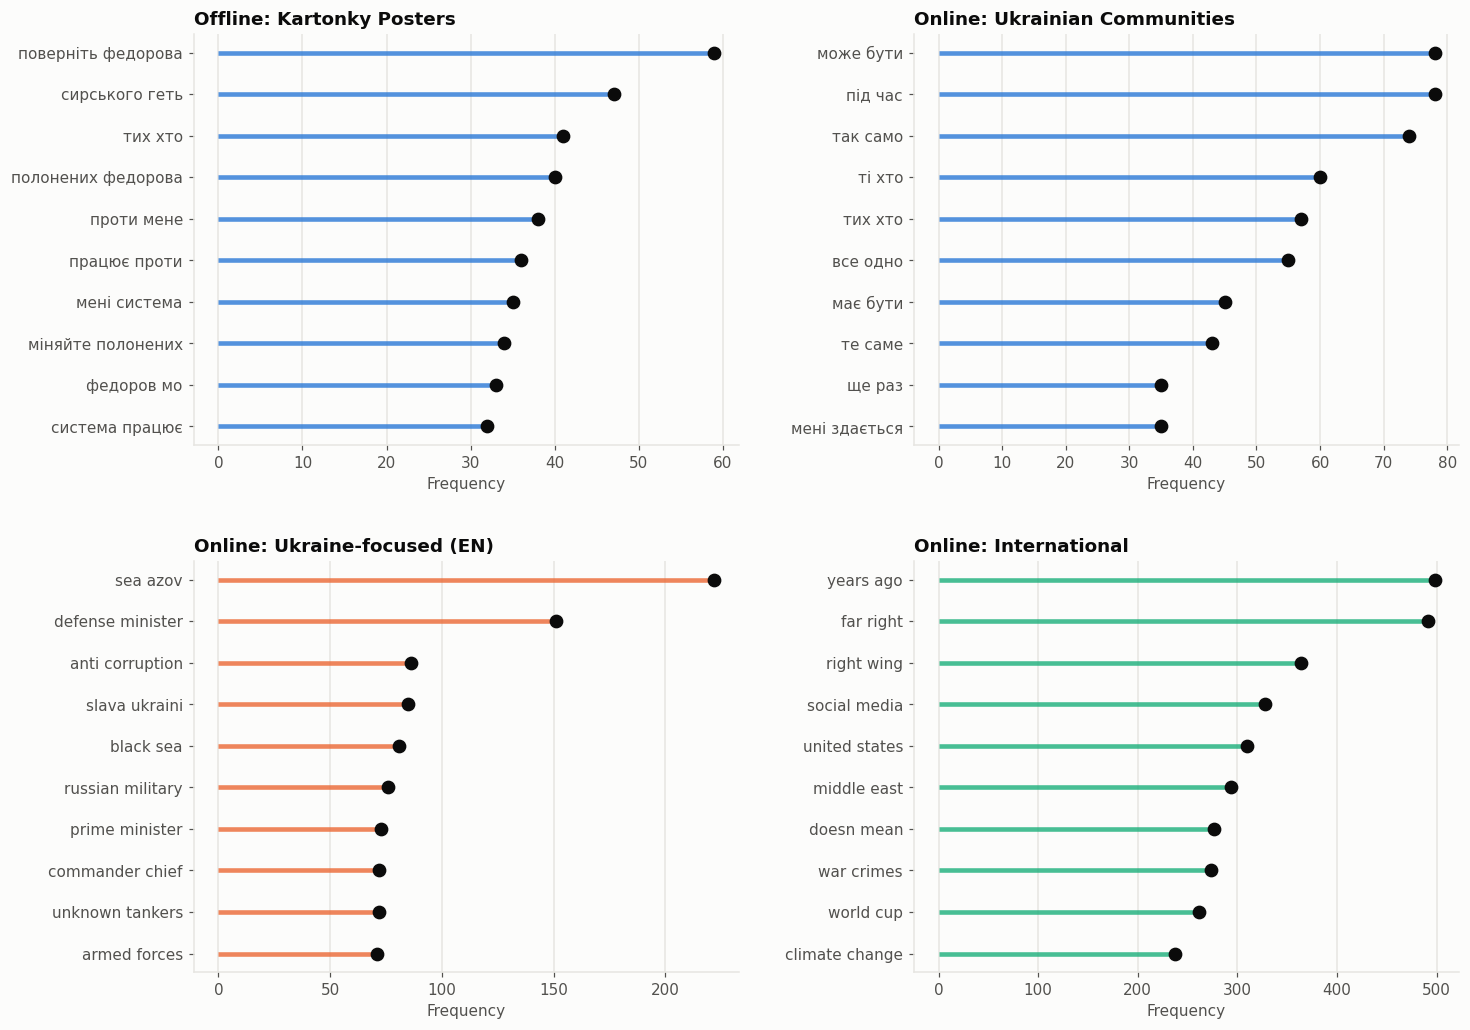

In [31]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

ua_stop_words = [
    "на", "не", "за", "це", "ми", "що", "до", "та", "як", "про", "для", "або",
    "з", "і", "у", "в", "а", "є", "то", "чи", "щоб", "але", "якщо",
    "від", "цей", "ця", "ці", "ти", "ви", "тут", "ж", "ну"
]

reddit_noise = [
    "https", "www", "com", "org", "wiki", "wikipedia", "en", "reddit", "removed", "deleted",
    "just", "like", "don", "looks", "ll", "ve", "re",
    "gt", "amp", "https www", "wikipedia org", "en wikipedia", "reddit com", "www reddit", "https en",
    "preview", "redd", "auto", "webp", "format", "pjpg", "jpeg", "width", "png", "gif", "giphy",
    "bsky", "app", "profile", "2026", "07"
]
custom_stop_words = list(ENGLISH_STOP_WORDS) + ua_stop_words + reddit_noise

comments_path = CLEAN / "reddit_comments.csv"
group_corpora = {g: [] for g in GROUP_ORDER}
cols = ["subreddit", "date_local", "body", "is_automod"]

for ch in pd.read_csv(comments_path, usecols=cols, dtype=str, keep_default_na=False, chunksize=200_000):
    valid_rows = (ch["is_automod"] != "True") & (ch["date_local"] >= "2026-07-15") & (ch["date_local"] <= "2026-07-20")
    valid_df = ch[valid_rows].copy()
    valid_df["group"] = valid_df["subreddit"].map(GROUPS)

    for g in GROUP_ORDER:
        texts = valid_df.loc[valid_df["group"] == g, "body"].str.lower().str.replace(r"[^\w\s]", " ", regex=True)
        group_corpora[g].extend(texts.tolist())

def get_top_ngrams_filtered(corpus, n=2, top_k=10, stop_words=None):
    corpus_clean = pd.Series(corpus[:100000]).dropna().astype(str)
    if corpus_clean.empty:
        return pd.DataFrame(columns=["word", "freq"])
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words).fit(corpus_clean)
    bag_of_words = vec.transform(corpus_clean)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    df = pd.DataFrame(sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k], columns=["word", "freq"])
    return df.sort_values("freq")

df_offline = get_top_ngrams_filtered(kartonky_peak["text_norm"].tolist(), n=2, top_k=10, stop_words=ua_stop_words)
df_ukr = get_top_ngrams_filtered(group_corpora["Ukrainian communities"], n=2, top_k=10, stop_words=custom_stop_words)
df_en = get_top_ngrams_filtered(group_corpora["Ukraine-focused (EN)"], n=2, top_k=10, stop_words=custom_stop_words)
df_intl = get_top_ngrams_filtered(group_corpora["International"], n=2, top_k=10, stop_words=custom_stop_words)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

datasets = [
    ("Offline: Kartonky Posters", df_offline, ACCENT),
    ("Online: Ukrainian Communities", df_ukr, SERIES["Ukrainian communities"]),
    ("Online: Ukraine-focused (EN)", df_en, SERIES["Ukraine-focused (EN)"]),
    ("Online: International", df_intl, SERIES["International"])
]

for ax, (title, df, color) in zip(axes, datasets):
    if not df.empty:
        ax.hlines(y=df["word"], xmin=0, xmax=df["freq"], color=color, linewidth=3, alpha=0.8)
        ax.plot(df["freq"], df["word"], "o", markersize=8, color=INK)
    ax.set_title(title, loc="left", weight="bold")
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Frequency")

fig.tight_layout(pad=3.0)
fig.savefig(FIG / "h4_lollipop_cross_comparison.png", dpi=200)
plt.show()

### 4.2. What the Keywords Tell Us (Conclusions for H1 & Thematic Focus)

Comparing the top word pairs across our groups gives us a reality check on our initial hypotheses:

1. **The Limits of Slogan Convergence (H1):** While the offline physical posters are focused on sharp, repetitive slogans ("поверніть федорова", "сирського геть"), the online **Ukrainian communities** don't simply parrot these chants. Their top bigrams ("так само", "все одно", "мені здається") reveal that users are engaged in debates rather than just copy-pasting protest mottos. This partially refutes H1.
2. **Clear Thematic Divergence:** The contrast between the English-speaking groups perfectly sets the stage for our sentiment analysis. The **Ukraine-focused (EN)** subreddits actively try to make sense of the domestic shake-up, focusing on macro-concepts like "defense minister", "anti corruption", and "commander chief". Meanwhile, the **International** cluster exists in a completely different news cycle—their top discussions revolve around "social media", the "united states", and the "world cup", entirely bypassing the Ukrainian political crisis.

### 4.3. Sentiment Polarity: Multilingual Transformer (Testing H2)

To accurately evaluate the emotional tone across all three subreddit clusters (Testing **H2: Sentiment Divergence**) without the loss of semantic nuance inherent in translation pipelines, we implement a pre-trained multilingual transformer model (`nlptown/bert-base-multilingual-uncased-sentiment`).

Since this model outputs discrete star ratings (1 to 5 stars), continuous boxplots are ineffective. Instead, we map these ratings into three core categorical polarities (Negative, Neutral, Positive) and visualize their proportional distribution across the communities using a 100% stacked bar chart.

P.S in the first iteration we wanted to see semantics using VADER lib, which is very fast and pretty accurate according to this [research](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41598-024-74032-0/MediaObjects/41598_2024_74032_MOESM1_ESM.pdf). But it didn't work out because it is only built for english text and translating ukrainian text was slower than using model

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

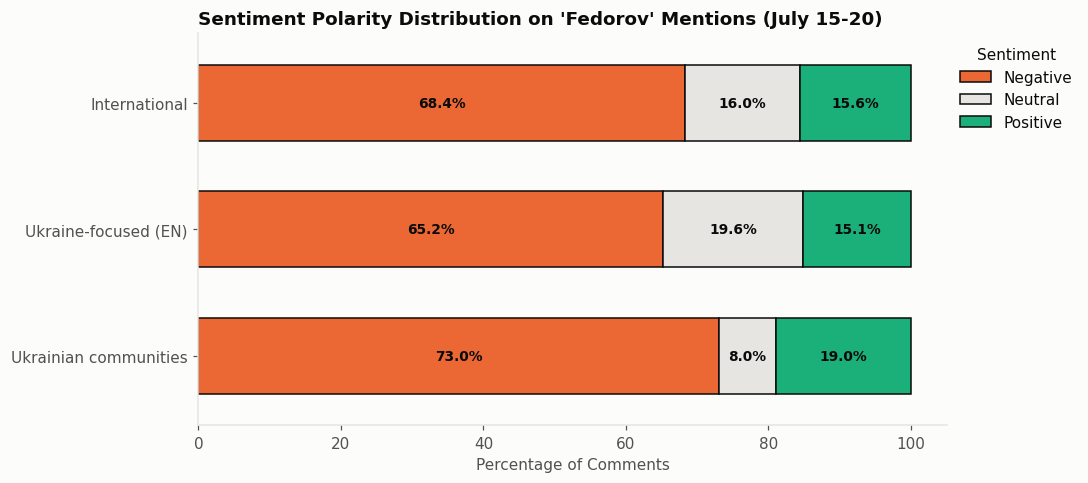

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

sentiment_data = []

comments_path = CLEAN / "reddit_comments.csv"
cols = ["subreddit", "date_local", "body", "is_automod"]

def get_categorical_sentiment(text):
    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        label = result['label']
        if label in ['1 star', '2 stars']:
            return 'Negative'
        elif label == '3 stars':
            return 'Neutral'
        else:
            return 'Positive'
    except Exception:
        return 'Neutral'

for ch in pd.read_csv(comments_path, usecols=cols, dtype=str, keep_default_na=False, chunksize=200_000):
    valid_rows = (ch["is_automod"] != "True") & (ch["date_local"] >= "2026-07-15") & (ch["date_local"] <= "2026-07-20")
    df_valid = ch[valid_rows].copy()

    hit_mask = df_valid["body"].str.contains(FEDOROV_REGEX, case=False, regex=True)
    df_hits = df_valid[hit_mask].copy()

    if not df_hits.empty:
        df_hits["group"] = df_hits["subreddit"].map(GROUPS)
        df_hits["sentiment"] = df_hits["body"].apply(get_categorical_sentiment)
        sentiment_data.append(df_hits[["group", "sentiment"]])

df_sentiment = pd.concat(sentiment_data, ignore_index=True)

sentiment_counts = df_sentiment.groupby(['group', 'sentiment']).size().unstack(fill_value=0)
sentiment_pct = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

sentiment_pct = sentiment_pct.reindex(GROUP_ORDER)
sentiment_pct = sentiment_pct[['Negative', 'Neutral', 'Positive']]

fig, ax = plt.subplots(figsize=(10, 4.5))

colors = ['#eb6834', '#e6e5e1', '#1baf7a'] # Negative (Red/Orange), Neutral (Grey), Positive (Green)
sentiment_pct.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.6, edgecolor=INK)

for c in ax.containers:
    labels = [f"{w:.1f}%" if w > 5 else "" for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color=INK, weight='bold', fontsize=9)

ax.set_title("Sentiment Polarity Distribution on 'Fedorov' Mentions (July 15-20)", loc="left", weight="bold")
ax.set_xlabel("Percentage of Comments")
ax.set_ylabel("")
ax.legend(title="Sentiment", frameon=False, bbox_to_anchor=(1.0, 1.0))
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=False)

fig.tight_layout()
plt.show()